# First steps in PyTorch

Complete the exercises **A)** - **J)** and print your results for each part.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

**A) Creating Tensor**

Create a tensor **x** with two rows and three columns (a (2 x 3) - tensor) which has [0,5,2,7] in the first row and [4,9,3,6] in the second row. <br>
Then, create a random tensor **y** with the same shape as **x**. <br>
Print the tensors **x** and **y**.

In [2]:
x = torch.tensor([[0, 5, 2, 7], [4, 9, 3, 6]], dtype=torch.double)
y = torch.rand(2, 4, dtype=torch.double)
print("x:", x)
print("y:", y)

x: tensor([[0., 5., 2., 7.],
        [4., 9., 3., 6.]], dtype=torch.float64)
y: tensor([[0.4247, 0.1270, 0.6555, 0.4588],
        [0.0473, 0.0818, 0.3750, 0.7067]], dtype=torch.float64)


**B) Manipulating Tensors**

Set the last column of **x** to the last column of **y**. Additionally, set the first element of the second row of **x** to the first element of the second row of **y**. <br>
Print the tensors **x** and **y**.

In [3]:
x[:, -1] = y[:, -1]
x[1, 0] = y[1, 0]
print("x:", x)
print("y:", y)

x: tensor([[0.0000, 5.0000, 2.0000, 0.4588],
        [0.0473, 9.0000, 3.0000, 0.7067]], dtype=torch.float64)
y: tensor([[0.4247, 0.1270, 0.6555, 0.4588],
        [0.0473, 0.0818, 0.3750, 0.7067]], dtype=torch.float64)


**C) Similarity to NumPy**

Do the same operation of **A)** and **B)** with numpy arrays.

In [4]:
x_np = np.array([[0, 5, 2, 7], [4, 9, 3, 6]], dtype=np.float64)
y_np = np.random.rand(2, 4)

x_np[:, -1] = y_np[:, -1]
x_np[1, 0] = y_np[1, 0]

print("x_np:", x_np)
print("y_np:", y_np)

x_np: [[0.         5.         2.         0.60302178]
 [0.3166379  9.         3.         0.91492074]]
y_np: [[0.79708347 0.76642183 0.3146233  0.60302178]
 [0.3166379  0.81828962 0.78857583 0.91492074]]


As you can see, the syntax and array/tensor handling of PyTorch is pretty close to the one of NumPy.

**D) Properties of tensors and arrays**

The last column of **x_np** is set to zero, although the last column of **y_np** does not equal zero. To investigate this, print the properties of **x**, **y**, **x_np** and **y_np**:
 - class name (see \_\_class\_\_)
 - shape
 - dtype (data type)

In [5]:
print("x class:", x.__class__)
print("x shape:", x.shape)
print("x dtype:", x.dtype)
print("y class:", y.__class__)
print("y shape:", y.shape)
print("y dtype:", y.dtype)
print("x_np class:", x_np.__class__)
print("x_np shape:", x_np.shape)
print("x_np dtype:", x_np.dtype)
print("y_np class:", y_np.__class__)
print("y_np shape:", y_np.shape)
print("y_np dtype:", y_np.dtype)

x class: <class 'torch.Tensor'>
x shape: torch.Size([2, 4])
x dtype: torch.float64
y class: <class 'torch.Tensor'>
y shape: torch.Size([2, 4])
y dtype: torch.float64
x_np class: <class 'numpy.ndarray'>
x_np shape: (2, 4)
x_np dtype: float64
y_np class: <class 'numpy.ndarray'>
y_np shape: (2, 4)
y_np dtype: float64


**E) Specifying properties**

Basic properties, such as **dtype** can be specified on instantiation of the tensors/arrays.

Redo **A)** and **B)** for PyTorch, but this time choose **dtype=torch.int**. Hint: for **y** you have to specify **torch.float**.

Redo **C)** for NumPy, but this time choose **dtype=float**.

In [6]:
x = torch.tensor([[0, 5, 2, 7], [4, 9, 3, 6]], dtype=torch.int)
y = torch.rand(2, 4, dtype=torch.float)

x[:, -1] = y[:, -1].int()
x[1, 0] = y[1, 0].int()

print("x:", x)
print("y:", y)

x_np = np.array([[0, 5, 2, 7], [4, 9, 3, 6]], dtype=float)
y_np = np.random.rand(2, 4).astype(float)
x_np[:, -1] = y_np[:, -1]
x_np[1, 0] = y_np[1, 0]

print("x_np:", x_np)
print("y_np:", y_np)

x: tensor([[0, 5, 2, 0],
        [0, 9, 3, 0]], dtype=torch.int32)
y: tensor([[0.9300, 0.1655, 0.5181, 0.0676],
        [0.3803, 0.3191, 0.5564, 0.1946]])
x_np: [[0.         5.         2.         0.85178544]
 [0.87514226 9.         3.         0.99853955]]
y_np: [[0.82314008 0.20243361 0.97790393 0.85178544]
 [0.87514226 0.53646941 0.17171755 0.99853955]]


You can observe the opposite behavior than before. Always keep in mind, choosing the right data types is important in many cases when working with tensors to avoid undesirable behavior, as we saw in these exercises.

**F) Typical tensor operations for deep neural networks (1/2)**

Below an input tensor **d** to a neural network is given. It represents one sample with four input features.

If a two dimensional tensor is given, the 0-axis usually corresponds to the samples and the 1-axis corresponds to the input features.
 - Check the shape of **d**.
 - Introduce a new axis to **d**, so that the shape is more meaningful and contains a sample-axis as well as feature-axis.

In [11]:
d = torch.tensor([1,2,3,4], dtype=torch.double)
print("Shape d:", d.shape)
d_extended = d.unsqueeze(0)
print("Shape d_extended:", d_extended.shape)
print("d_extended:", d_extended)

Shape d: torch.Size([4])
Shape d_extended: torch.Size([1, 4])
d_extended: tensor([[1., 2., 3., 4.]], dtype=torch.float64)


**G) Typical tensor operations for deep neural networks (2/2)**

Suppose you get another input (3x5)-tensor **e** (think before coding: how many samples and features does **e** represent?).

We want to somehow 'merge' the input vector **d_extended** with **e** to obtain a new tensor **ed_merged** with three samples and nine input features. Unfortunately the dimensions do not match yet.
 - Create **e** as a random tensor with the given shape.
 - Repeat **d_extended** over the sample-axis to match the number of samples given in **e**. (see _torch.repeat_)
 - Merge the two tensor over the feature-axis (think before coding: what is the shape of the new tensor **ed_merged**?).

In [13]:
e = torch.rand(3, 5, dtype=torch.double)
print("Shape e:", e.shape)
print("e:", e)

d_extended2 = d_extended.repeat(3, 1)
print("Shape d_extended2:", d_extended2.shape)
print("d_extended2:", d_extended2)

ed_merged = torch.cat([d_extended2, e], dim=1)
print("Shape ed_merged:", ed_merged.shape)
print("ed_merged:", ed_merged)

Shape e: torch.Size([3, 5])
e: tensor([[0.4105, 0.7176, 0.7087, 0.0756, 0.8419],
        [0.4415, 0.7868, 0.2914, 0.9216, 0.9210],
        [0.5448, 0.3099, 0.3831, 0.6410, 0.0913]], dtype=torch.float64)
Shape d_extended2: torch.Size([3, 4])
d_extended2: tensor([[1., 2., 3., 4.],
        [1., 2., 3., 4.],
        [1., 2., 3., 4.]], dtype=torch.float64)
Shape ed_merged: torch.Size([3, 9])
ed_merged: tensor([[1.0000, 2.0000, 3.0000, 4.0000, 0.4105, 0.7176, 0.7087, 0.0756, 0.8419],
        [1.0000, 2.0000, 3.0000, 4.0000, 0.4415, 0.7868, 0.2914, 0.9216, 0.9210],
        [1.0000, 2.0000, 3.0000, 4.0000, 0.5448, 0.3099, 0.3831, 0.6410, 0.0913]],
       dtype=torch.float64)


**H) Maths with tensors**

Define three random tensors:
 - **a** has shape (3,4)
 - **b** has shape (3,4)
 - **c** has shape (1,4)

Think about the following matrix multiplications, whether they are well-defined. Then implement them (with **x.T** being the transposed tensor of **x**):
 - **a** x **b.T**
 - **b** x **c.T**
 - **a.T** x **c**

Also try to understand the _error message_, if one is given. Remove the multiplication(s) which is/are not well-defined in order to obtain running python code.

In [16]:
a = torch.rand(3, 4)
b = torch.rand(3, 4)
c = torch.rand(1, 4)

print("a shape:", a.shape)
print("b shape:", b.shape)
print("c shape:", c.shape)

result1 = torch.matmul(a, b.T)
print("a x b.T shape:", result1.shape)
print("a x b.T:", result1)

result2 = torch.matmul(b, c.T)
print("b x c.T shape:", result2.shape)
print("b x c.T:", result2)

#result3 = torch.matmul(a.T, c) this gives an error since a.T is 4x3 and multpilcation with 1x4 gives error, instead we can a x c.T

result3 = torch.matmul(a, c.T)
print("a x c.T shape:", result3.shape)
print("a x c.T:", result3)


a shape: torch.Size([3, 4])
b shape: torch.Size([3, 4])
c shape: torch.Size([1, 4])
a x b.T shape: torch.Size([3, 3])
a x b.T: tensor([[0.9578, 0.5073, 0.8089],
        [1.7828, 0.9896, 1.2481],
        [1.2322, 0.7285, 0.9150]])
b x c.T shape: torch.Size([3, 1])
b x c.T: tensor([[0.8221],
        [0.5564],
        [0.5493]])
a x c.T shape: torch.Size([3, 1])
a x c.T: tensor([[0.5245],
        [0.9127],
        [0.6981]])


**I) Typical maths operations for deep neural networks**

Suppose **a** is the prediction of a neural network and **b** is the ground truth. As repitition: Each row of **a** and **b** represent one sample. Each column of **a** represents one output of the neural network, and each column of **b** represents one feature of the ground truth.

In order to evaluate the error of the neural network do the following steps:
 - calculate the squared error for each sample and each feature
 - calculate the mean squared error for each sample
 - calculate the mean squared error for each feature
 - calculate the mean squared error of **a** and **b**
 - print the value and position of highest squared error

In [18]:
sq_errors = (a - b) ** 2
print("Squared errors:", sq_errors)

sq_error_per_sample = sq_errors.mean(dim=1)
print("Squared error per sample:", sq_error_per_sample)

sq_error_per_feature = sq_errors.mean(dim=0)
print("Squared error per feature:", sq_error_per_feature)

mse = sq_errors.mean()
print("MSE:", mse)
value_max_sq_error = sq_errors.max()
pos_max_sq_error = sq_errors.argmax()
pos_2d = (pos_max_sq_error // sq_errors.shape[1], pos_max_sq_error % sq_errors.shape[1])

print("Value of max error:", value_max_sq_error.item())
print("Position of max error (flattened):", pos_max_sq_error.item())
print("Position of max error (2D):", pos_2d)

Squared errors: tensor([[0.4036, 0.2804, 0.0963, 0.0510],
        [0.2156, 0.0087, 0.6902, 0.2300],
        [0.0469, 0.0457, 0.0119, 0.0614]])
Squared error per sample: tensor([0.2078, 0.2861, 0.0415])
Squared error per feature: tensor([0.2221, 0.1116, 0.2661, 0.1141])
MSE: tensor(0.1785)
Value of max error: 0.6901804804801941
Position of max error (flattened): 6
Position of max error (2D): (tensor(1), tensor(2))


**J) Visualization**

Analysing all the numbers of **I)** can be tedious, especially when the problem becomes higher dimensional.

Print a bar plot with matplotlib to visualize the squared error per feature.

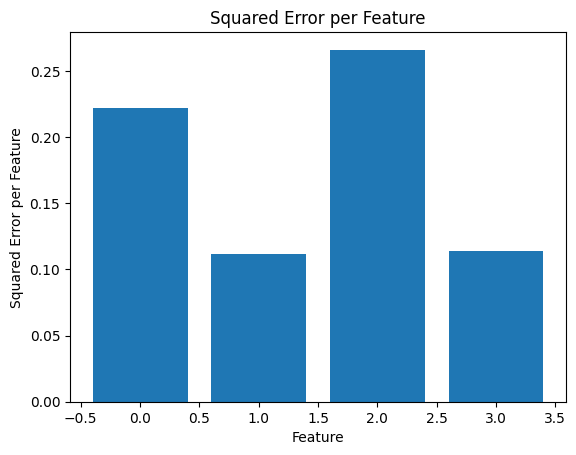

In [19]:
plt.bar(range(len(sq_error_per_feature)), sq_error_per_feature.numpy())
plt.xlabel('Feature')
plt.ylabel('Squared Error per Feature')
plt.title('Squared Error per Feature')
plt.show()